## Import modules

In [1]:
import csv
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sn  #Per heatmap
import time
import scipy as sp
import os

Audio-specific modules

In [2]:
import librosa as lb
import librosa.display

Sklearn modules

In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder,OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, ParameterGrid, train_test_split
from sklearn.ensemble import RandomForestRegressor

## Load data

In [4]:
data = pd.read_csv('../../data/development.csv', index_col=0) #### USA SEMPRE .././data/NOME_FILE o .././data/NOME_CARTELLA per accedere ai dati

In [5]:
display(data)

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893,audios_development/1.wav
1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662,audios_development/2.wav
2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998,audios_development/3.wav
3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127,audios_development/4.wav
4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905,audios_development/5.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,[184.5703125],-100.921055,69,281,11,17.461406,audios_development/2929.wav
2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,[83.35433468],6.757283,0,0,1,1.509206,audios_development/2930.wav
2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,[89.10290948],-53.913449,1,9,1,1.645034,audios_development/2931.wav


## Data Extraction

In [6]:
audio_files = os.listdir('../../data/audios_development')
len(audio_files)

2933

In [7]:
audio_files[:10]

['1.wav',
 '10.wav',
 '100.wav',
 '1000.wav',
 '1001.wav',
 '1002.wav',
 '1003.wav',
 '1004.wav',
 '1005.wav',
 '1006.wav']

### Single example

In [8]:
y, sr = lb.load('../../data/audios_development/' + audio_files[0])
y, len(y), sr

(array([-0.00048187, -0.00066003, -0.00036648, ...,  0.00093829,
         0.00074567,  0.0010901 ], dtype=float32),
 773850,
 22050)

In [9]:
spectrogram = lb.feature.melspectrogram(y=y, sr=sr, n_mels=40)
log_spectrogram = lb.power_to_db(spectrogram, ref=np.max)

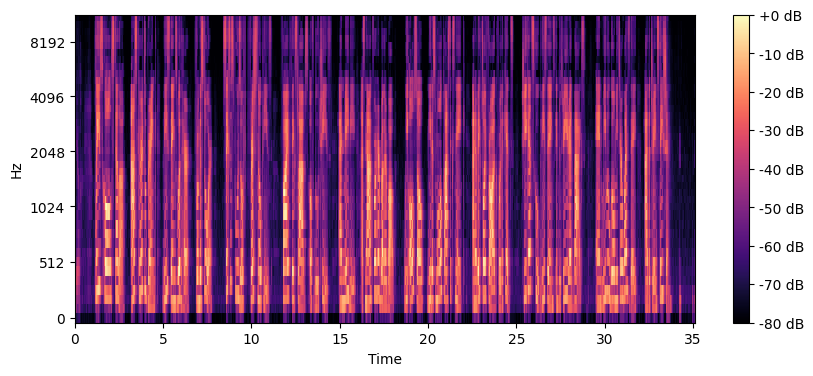

In [10]:
plt.figure(figsize=(10, 4))
lb.display.specshow(log_spectrogram, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

In [11]:
y_trimmed= lb.effects.trim(y,top_db=40)
len(y_trimmed[0])

756224

In [12]:
display(y_trimmed)

(array([ 1.5456248e-03,  1.4104634e-03, -5.1184610e-04, ...,
        -3.0053561e-04,  4.2263950e-05, -4.8543248e-04], dtype=float32),
 array([  1024, 757248]))

In [13]:
spectrogram_trim = lb.feature.melspectrogram(y=y_trimmed[0], sr=sr, n_mels=40)
log_spectrogram_trim = lb.power_to_db(spectrogram, ref=np.max)

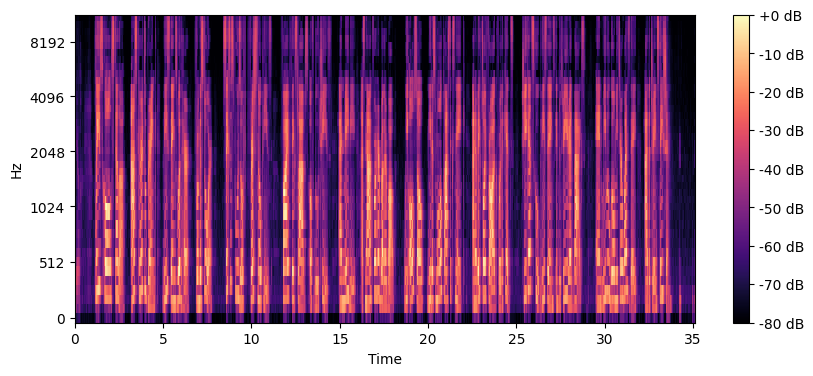

In [14]:
plt.figure(figsize=(10, 4))
lb.display.specshow(log_spectrogram_trim, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')

### General functions

In [15]:
def load_data(audio_files, folder_path):
    time_stamps = []
    audio_arrays = []
    for file_name in audio_files:
        if file_name.endswith(".wav"):
            audio_array = librosa.load(folder_path + file_name)
            trimmed_audio_array= lb.effects.trim(audio_array[0])
            time_stamps.append(len(trimmed_audio_array[0]))
            audio_arrays.append(trimmed_audio_array[0])
    return (audio_arrays, np.array(time_stamps))

In [16]:
audio_arrays,time_stamps = load_data(audio_files, '../../data/audios_development/')

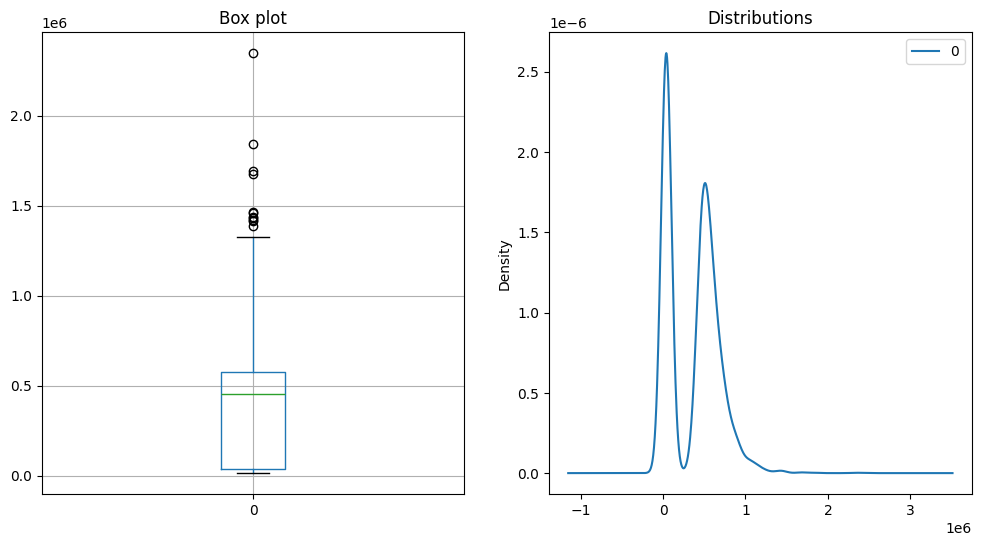

In [17]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
pd.DataFrame(time_stamps).boxplot(ax=axs[0])
axs[0].set_title('Box plot')
pd.DataFrame(time_stamps).plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
plt.show()

In [28]:
time_stamps_values

array([  14737,   16655,   17726, ..., 1692160, 1841152, 2346559])

In [35]:
#2,4 10^5
time_stamps_values, time_stamps_counts = np.unique(time_stamps, return_counts=True)
time_stamps_array =np.vstack([time_stamps_values,time_stamps_counts])
print(time_stamps_array)


#fig = plt.figure(figsize=(9,3))
#plt.bar(time_stamps_values[time_stamps_values], time_stamps_counts)
#plt.show()

[[  14737   16655   17726 ... 1692160 1841152 2346559]
 [      1       1       1 ...       1       1       1]]


In [18]:
print('Minimum number of samplings:',min(time_stamps))
print('Maximum number of samplings:',max(time_stamps))
print('Mean number of samplings:',np.mean(time_stamps))
print('Ratio between maximum and minimum number of samplings:',max(time_stamps)/min(time_stamps))
print('Ratio between mean and minimum number of samplings:',np.mean(time_stamps)/min(time_stamps))

Minimum number of samplings: 14737
Maximum number of samplings: 2346559
Mean number of samplings: 364163.85714285716
Ratio between maximum and minimum number of samplings: 159.2290832598222
Ratio between mean and minimum number of samplings: 24.71085411839975


In [19]:
np.argmax(time_stamps)

np.int64(21)

In [20]:
def remove_silence(audio_array):
    return 1

In [21]:
def extract_features(audio_arrays):
    features_silence = []
    features_no_silence = []
    for audio in audio_arrays:
        #remove silence
        #standardizzazione delle lunghezze
        spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
        log_spectrogram = librosa.power_to_db(spectrogram, ref=np.max)
        features_silence.append(fs)
        features_no_silence.append(fns)

    

    # Extract statistical features
    features = np.concatenate([
        np.mean(log_spectrogram, axis=1),  # Mean across time
        np.std(log_spectrogram, axis=1),  # Standard deviation across time
    ])
    return (features_silence, features_no_silence)

## Features exploration

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2933 entries, 0 to 2932
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sampling_rate           2933 non-null   int64  
 1   age                     2933 non-null   float64
 2   gender                  2933 non-null   object 
 3   ethnicity               2933 non-null   object 
 4   mean_pitch              2933 non-null   float64
 5   max_pitch               2933 non-null   float64
 6   min_pitch               2933 non-null   float64
 7   jitter                  2933 non-null   float64
 8   shimmer                 2933 non-null   float64
 9   energy                  2933 non-null   float64
 10  zcr_mean                2933 non-null   float64
 11  spectral_centroid_mean  2933 non-null   float64
 12  tempo                   2933 non-null   object 
 13  hnr                     2933 non-null   float64
 14  num_words               2933 non-null   int64

#### Age

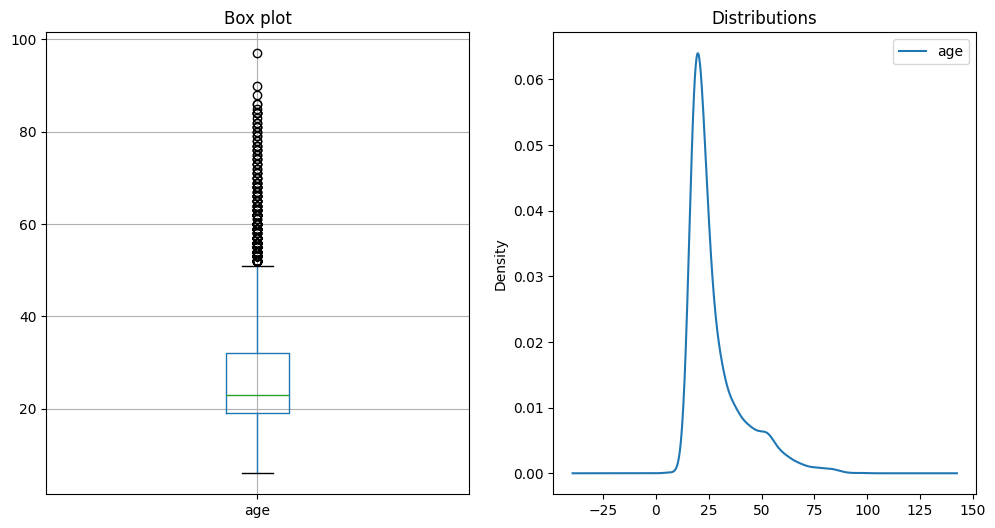

In [23]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
data[['age']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
data[['age']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
plt.show()

#### Sampling rate

In [24]:
sampling_rate=data['sampling_rate'].unique()[0]
print(sampling_rate)

22050


#### Gender

In [25]:
display(data['gender'][data['gender']=='female'].shape)
display(data['gender'][data['gender']=='male'].shape)

(1468,)

(1465,)

#### Ethnicity

In [26]:
data['ethnicity'].unique().shape

(165,)

In [1]:
ethnicity_values, ethnicity_counts = np.unique(data['ethnicity'], return_counts=True)
ethnicity_data = pd.DataFrame(np.vstack((ethnicity_values,ethnicity_counts)).transpose(), columns=['value','count'])
ethnicity_data_ordered = ethnicity_data.sort_values(by=['count'], ascending=False)
display(ethnicity_data_ordered.iloc[:,:])

fig = plt.figure(figsize=(12,12))
plt.bar(ethnicity_data_ordered['value'].iloc[:20], ethnicity_data_ordered['count'].iloc[:20])
plt.axhline(100, c='red')
plt.show()

NameError: name 'np' is not defined

#### Pitch

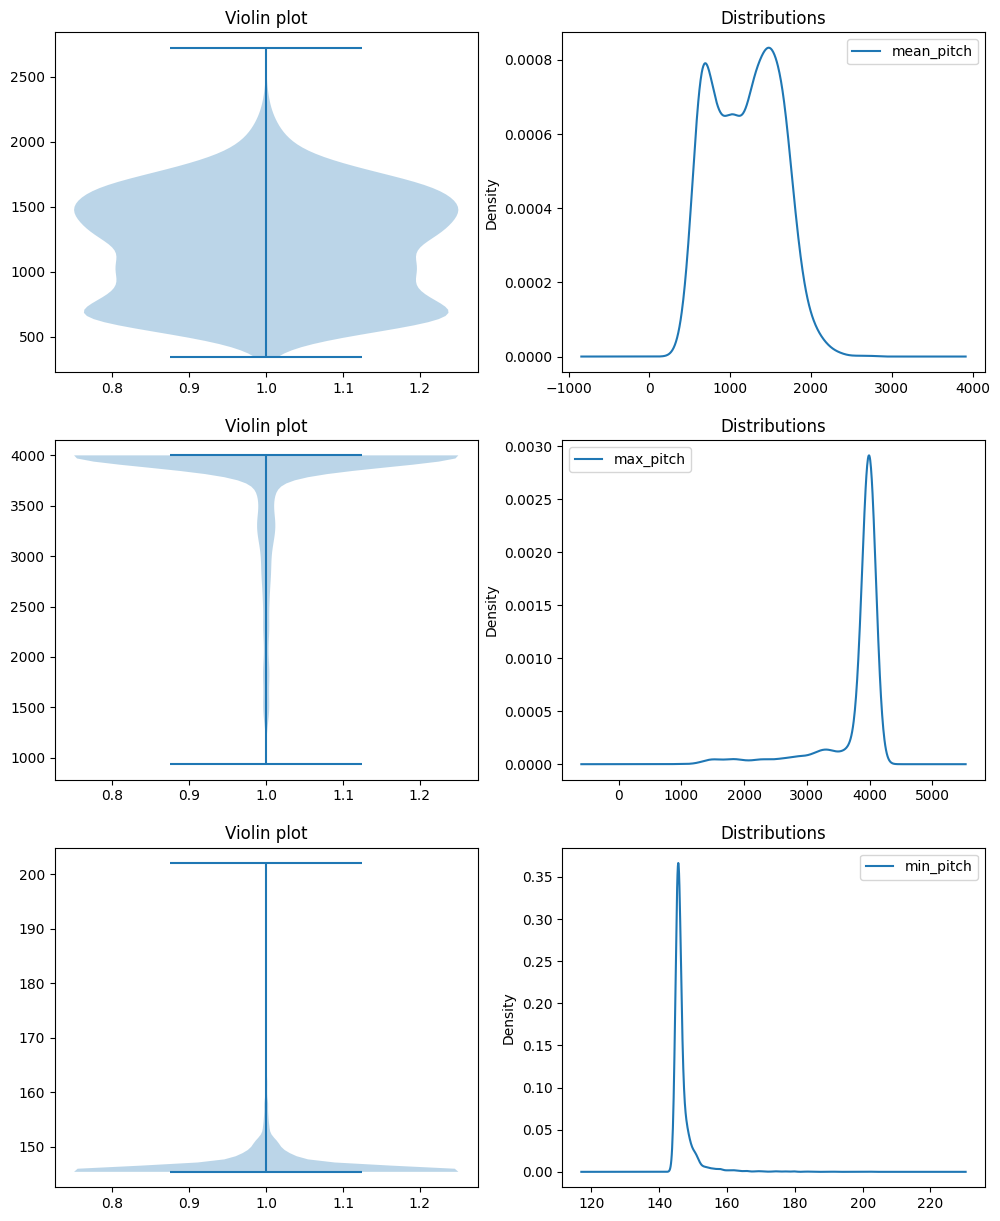

In [49]:
fig, axs = plt.subplots(3,2, figsize=(12,15))
axs[0,0].violinplot(data[['mean_pitch']])
axs[0,0].set_title('Violin plot')
data[['mean_pitch']].plot.density(ax=axs[0,1],legend=True)
axs[0,1].set_title('Distributions')
axs[1,0].violinplot(data[['max_pitch']])
axs[1,0].set_title('Violin plot')
data[['max_pitch']].plot.density(ax=axs[1,1],legend=True)
axs[1,1].set_title('Distributions')
axs[2,0].violinplot(data[['min_pitch']])
axs[2,0].set_title('Violin plot')
data[['min_pitch']].plot.density(ax=axs[2,1],legend=True)
axs[2,1].set_title('Distributions')
plt.show()

In [16]:
max_pitch_values, max_pitch_counts = np.unique(np.floor(data['max_pitch']), return_counts=True)

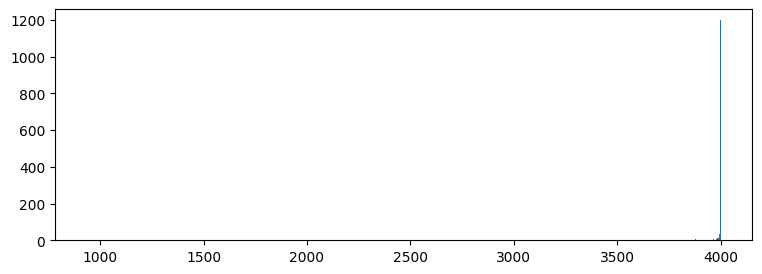

In [17]:
fig = plt.figure(figsize=(9,3))
plt.bar(max_pitch_values, max_pitch_counts)
plt.show()

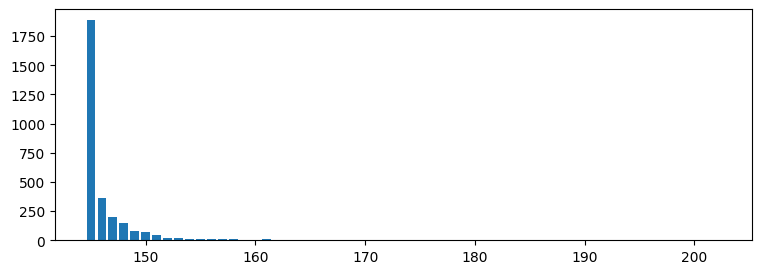

In [18]:
min_pitch_values, min_pitch_counts = np.unique(np.floor(data['min_pitch']), return_counts=True)
fig = plt.figure(figsize=(9,3))
plt.bar(min_pitch_values, min_pitch_counts)
plt.show()

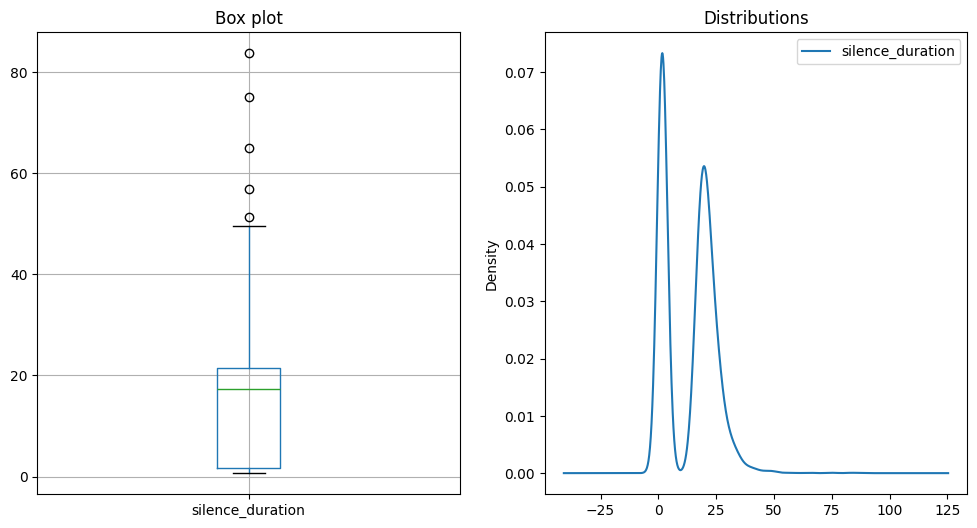

In [19]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
data[['silence_duration']].boxplot(ax=axs[0])
axs[0].set_title('Box plot')
data[['silence_duration']].plot.density(ax=axs[1],legend=True)
axs[1].set_title('Distributions')
plt.show()

### Other given sound features

- Vedere come sono diverse su audio 21
- Valutare di aggiungere la durata dell'audio (trimmato) tra le feature

### Correlation

In [20]:
display(data.iloc[:,4:-1])

,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration
Id,,,,,,,,,,,,,,
0,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893
1,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662
2,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998
3,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127
4,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,[184.5703125],-100.921055,69,281,11,17.461406
2929,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,[83.35433468],6.757283,0,0,1,1.509206
2930,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,[89.10290948],-53.913449,1,9,1,1.645034


,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration
mean_pitch,1.000000,0.775332,-0.447558,0.142360,0.146592,0.101621,0.820542,0.568356,-0.142605,-0.516533,0.686012,0.680059,0.593105,0.529191
max_pitch,0.775332,1.000000,-0.593449,0.303911,0.244829,0.230829,0.757758,0.410730,-0.143951,-0.635859,0.803504,0.800896,0.704005,0.699909
min_pitch,-0.447558,-0.593449,1.000000,-0.376627,-0.279662,-0.278149,-0.476273,-0.139575,0.112452,0.611926,-0.695436,-0.697176,-0.614867,-0.657855
jitter,0.142360,0.303911,-0.376627,1.000000,0.590752,0.214657,0.169770,-0.031400,-0.129682,-0.344261,0.439897,0.444313,0.218080,0.352114
shimmer,0.146592,0.244829,-0.279662,0.590752,1.000000,-0.113531,0.175143,0.104499,-0.087105,-0.359411,0.310839,0.313879,0.097301,0.285812
energy,0.101621,0.230829,-0.278149,0.214657,-0.113531,1.000000,0.120008,-0.164092,-0.066052,-0.053064,0.334832,0.334561,0.271859,0.285490
zcr_mean,0.820542,0.757758,-0.476273,0.169770,0.175143,0.120008,1.000000,0.764955,-0.159758,-0.513871,0.739197,0.741725,0.608227,0.551559
spectral_centroid_mean,0.568356,0.410730,-0.139575,-0.031400,0.104499,-0.164092,0.764955,1.000000,-0.088259,-0.187742,0.337451,0.346210,0.212938,0.208120
tempo,-0.142605,-0.143951,0.112452,-0.129682,-0.087105,-0.066052,-0.159758,-0.088259,1.000000,0.100703,-0.165144,-0.165492,-0.091526,-0.134210
hnr,-0.516533,-0.635859,0.611926,-0.344261,-0.359411,-0.053064,-0.513871,-0.187742,0.100703,1.000000,-0.724930,-0.731466,-0.750410,-0.709700


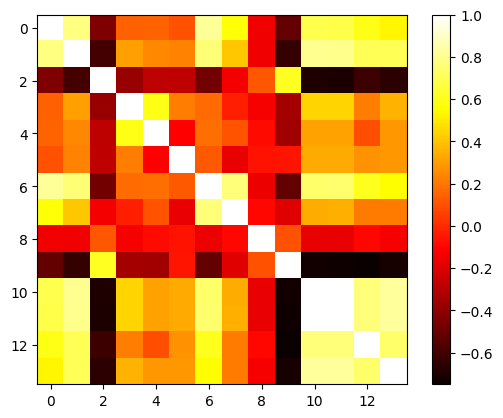

In [21]:
res = sp.stats.spearmanr(data.iloc[:,4:-1])
display(pd.DataFrame(res.statistic, index=data.iloc[:,4:-1].columns, columns=data.iloc[:,4:-1].columns))
plt.imshow(res[0], cmap='hot', interpolation='nearest')
plt.colorbar()
plt.show()

## Feature selection, creation and extraction

sampling_rate           2933 non-null   int64  
 1   age                     2933 non-null   float64
 2   gender                  2933 non-null   object 
 3   ethnicity               2933 non-null   object 
 4   mean_pitch              2933 non-null   float64
 5   max_pitch               2933 non-null   float64
 6   min_pitch               2933 non-null   float64
 7   jitter                  2933 non-null   float64
 8   shimmer                 2933 non-null   float64
 9   energy                  2933 non-null   float64
 10  zcr_mean                2933 non-null   float64
 11  spectral_centroid_mean  2933 non-null   float64
 12  tempo                   2933 non-null   object 
 13  hnr                     2933 non-null   float64
 14  num_words               2933 non-null   int64  
 15  num_characters          2933 non-null   int64  
 16  num_pauses              2933 non-null   int64  
 17  silence_duration        2933 non-null   float64
 18  path                    2933 non-null   object 

Da capire correlazione tra jitter e shimmer

### Person features

gender, ethnicity

### Sound given features

mean_pitch, jitter, shimmer, energy, zcr_mean, tempo, hnr, num_words

### Sound extracted features